# 🚀 Lab 19: Analyze Transportation Delay Dataset

### 📘 Lab Overview
In this lab, you will work with a transportation delay dataset and learn how to clean, filter, group, and analyze real-world style operational data using Python and pandas. Transportation systems generate large amounts of tabular data, but before that data can be analyzed properly, date and time fields must be standardized, missing values handled, and the dataset narrowed to the region of interest.

You will create a sample transportation delay dataset, load it from CSV, clean date and time columns, filter the data by city, group it by transport type, and calculate delay statistics such as average delay. You will also generate summary tables, charts, and a final analysis report.

This lab has been adapted for Google Colab so that everything runs directly inside a notebook environment without needing Linux terminal access, local Jupyter setup, or manual file uploads.

### 🎯 Objectives
By the end of this lab, students will be able to:
*   Load and examine transportation delay data from CSV files using Python pandas
*   Clean and standardize date and time columns for proper data analysis
*   Filter datasets by specific cities to focus analysis on targeted regions
*   Group data by transportation type to organize information effectively
*   Calculate average delay times to identify patterns and performance metrics
*   Apply basic data manipulation techniques for real-world transportation analysis

### 🧰 Prerequisites
Before starting this lab, students should have:
*   Basic understanding of Python programming concepts (variables, functions, loops)
*   Familiarity with tabular data and CSV file format
*   Basic knowledge of data structures like lists and dictionaries
*   Understanding of dataset organization into rows and columns
*   No prior experience with pandas is required; the lab will guide the workflow step by step

## ⚙️ Environment Setup

### 💡 ELI10: What are we doing?
Before we can start playing with data, we need to bring in our 'toolboxes' (libraries). Think of **pandas** as a super-powered Excel for Python, **numpy** as a math expert, and **matplotlib** as our artist for drawing charts. We also create a folder called `data` to keep our files organized, just like on a real computer.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings

# Ignore warning messages to keep the output clean for students
warnings.filterwarnings('ignore')

# Verify the environment and versions
print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

# Create a data directory to simulate a real-world project structure
# 'exist_ok=True' prevents an error if the folder already exists
os.makedirs("data", exist_ok=True)
print("Data directory ready:", os.path.abspath("data"))

Libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 2.0.2
Data directory ready: /content/data


## 🚍 Creating the Transportation Dataset

### 💡 ELI10: What are we doing?
Since we don't have a real file yet, we are going to write a script that acts like a 'factory.' It will create 250 fake transport records (buses, trains, etc.) with random delays and different cities. We even add some 'messy' data (like missing times or weird formats) because real-world data is rarely perfect!

In [9]:
# Set random seed for reproducibility so everyone gets the same 'random' results
np.random.seed(42)

cities = ['New York', 'Chicago', 'Los Angeles', 'Boston', 'San Francisco']
transport_types = ['Bus', 'Train', 'Metro', 'Flight', 'Ferry']

# Generate 250 sample records
n_records = 250
base_dates = pd.date_range(start='2024-01-01', periods=60, freq='D')

def random_time_string():
    """
    Create time strings in mixed real-world formats to practice cleaning.
    Formats: HH:MM, HHMM, and strings with extra spaces.
    """
    hour = np.random.randint(0, 24)
    minute = np.random.choice([0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55])
    format_type = np.random.choice(['colon', 'compact', 'spaced'])

    if format_type == 'colon':
        return f"{hour:02d}:{minute:02d}"
    elif format_type == 'compact':
        return f"{hour:02d}{minute:02d}"
    else:
        return f" {hour:02d}:{minute:02d} "

rows = []
for i in range(1, n_records + 1):
    # Weighted city selection to ensure New York has plenty of records
    city = np.random.choice(cities, p=[0.30, 0.20, 0.20, 0.15, 0.15])
    transport = np.random.choice(transport_types)
    # Fix: Ensure the choice is a pandas Timestamp to use strftime
    departure_date = pd.to_datetime(np.random.choice(base_dates)).strftime('%Y-%m-%d')
    departure_time = random_time_string()

    # Simulate realistic delay behaviors by transport type using normal distributions
    if transport == 'Metro':
        delay = max(0, np.random.normal(6, 4))
    elif transport == 'Train':
        delay = max(0, np.random.normal(12, 7))
    elif transport == 'Bus':
        delay = max(0, np.random.normal(15, 10))
    elif transport == 'Flight':
        delay = max(0, np.random.normal(22, 18))
    else:
        delay = max(0, np.random.normal(10, 6))

    # Calculate arrival based on duration and delay
    scheduled_duration = np.random.randint(20, 180)
    arrival_minutes_total = scheduled_duration + int(round(delay))

    # Simple logic to extract hours/minutes for the arrival calculation
    clean_dep = str(departure_time).strip().replace(':', '')
    dep_hour = int(clean_dep[:2])
    dep_minute = int(clean_dep[2:4])

    total_minutes = dep_hour * 60 + dep_minute + arrival_minutes_total
    arr_hour = (total_minutes // 60) % 24
    arr_minute = total_minutes % 60

    arrival_time = f"{arr_hour:02d}:{arr_minute:02d}" if np.random.rand() > 0.5 else f"{arr_hour:02d}{arr_minute:02d}"

    rows.append({
        'trip_id': f"T{i:04d}",
        'origin_city': city,
        'transport_type': transport,
        'departure_date': departure_date,
        'departure_time': departure_time,
        'arrival_time': arrival_time,
        'delay_minutes': round(delay, 1)
    })

transport_df_source = pd.DataFrame(rows)

# Introduce realistic missing values for cleaning practice
transport_df_source.loc[np.random.choice(transport_df_source.index, 5, replace=False), 'departure_time'] = np.nan
transport_df_source.loc[np.random.choice(transport_df_source.index, 3, replace=False), 'delay_minutes'] = np.nan
transport_df_source.loc[np.random.choice(transport_df_source.index, 2, replace=False), 'origin_city'] = np.nan

# Save to CSV in the data folder we created earlier
transport_df_source.to_csv('data/transport_delays.csv', index=False)

print("Sample transportation delay dataset created and saved to data/transport_delays.csv!")
display(transport_df_source.head())

Sample transportation delay dataset created and saved to data/transport_delays.csv!


,trip_id,origin_city,transport_type,departure_date,departure_time,arrival_time,delay_minutes
0,T0001,Chicago,Ferry,2024-01-15,10:35,1212,2.8
1,T0002,Chicago,Metro,2024-01-22,2005,2117,NaN
2,T0003,San Francisco,Bus,2024-01-12,21:55,2252,23.2
3,T0004,Boston,Metro,2024-02-13,22:15,00:45,0.0
4,T0005,NaN,Bus,2024-02-08,17:15,1907,9.0


## 📂 Task 1: Load Transport Delay CSV

### 💡 ELI10: What are we doing?
Now we act like a data scientist starting their day. We load that CSV file into a DataFrame (our virtual table) and look at the 'shape' (how many rows/cols) and the first few rows to see what we're working with.

In [10]:
# Subtask 1.3: Load the Transportation Dataset
# We use pd.read_csv to bring the file into our memory as a DataFrame
df = pd.read_csv('data/transport_delays.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

# Subtask 1.4: Examine Dataset Structure
# .info() tells us the data types and if any columns have missing (null) values
print("\nDataset Info:")
df.info()

print("\nMissing Values per Column:")
print(df.isnull().sum())

# .describe() gives us a statistical summary (mean, max, etc.)
print("\nBasic Statistics:")
display(df.describe(include='all'))

Dataset Shape: (250, 7)

Column Names: ['trip_id', 'origin_city', 'transport_type', 'departure_date', 'departure_time', 'arrival_time', 'delay_minutes']

First 5 rows:


,trip_id,origin_city,transport_type,departure_date,departure_time,arrival_time,delay_minutes
0,T0001,Chicago,Ferry,2024-01-15,10:35,1212,2.8
1,T0002,Chicago,Metro,2024-01-22,2005,2117,NaN
2,T0003,San Francisco,Bus,2024-01-12,21:55,2252,23.2
3,T0004,Boston,Metro,2024-02-13,22:15,00:45,0.0
4,T0005,NaN,Bus,2024-02-08,17:15,1907,9.0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   trip_id         250 non-null    object 
 1   origin_city     248 non-null    object 
 2   transport_type  250 non-null    object 
 3   departure_date  250 non-null    object 
 4   departure_time  245 non-null    object 
 5   arrival_time    250 non-null    object 
 6   delay_minutes   247 non-null    float64
dtypes: float64(1), object(6)
memory usage: 13.8+ KB

Missing Values per Column:
trip_id           0
origin_city       2
transport_type    0
departure_date    0
departure_time    5
arrival_time      0
delay_minutes     3
dtype: int64

Basic Statistics:


,trip_id,origin_city,transport_type,departure_date,departure_time,arrival_time,delay_minutes
count,250,248,250,250,245,250,247.000000
unique,250,5,5,59,217,240,NaN
top,T0001,New York,Ferry,2024-02-13,21:55,1907,NaN
freq,1,66,61,9,4,3,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,13.231579
std,NaN,NaN,NaN,NaN,NaN,NaN,10.519848
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,6.250000
50%,NaN,NaN,NaN,NaN,NaN,NaN,10.500000
75%,NaN,NaN,NaN,NaN,NaN,NaN,17.850000


## 🧹 Task 2: Clean Date and Time Columns

### 💡 ELI10: What are we doing?
Computers are picky! '14:30' and '1430' look the same to us, but the computer doesn't know they both mean 2:30 PM. We are going to write a 'cleaning function' to make every time look like **HH:MM** and every date look like a standardized **Year-Month-Day** format.

In [11]:
# Subtask 2.1 & 2.2: Convert Date Column
# We convert the text dates into actual 'datetime' objects so Python understands time logic
df['departure_date'] = pd.to_datetime(df['departure_date'], format='%Y-%m-%d', errors='coerce')

# Subtask 2.3: Clean and Standardize Time Columns
def clean_time_format(time_str):
    """
    Logic: Strip spaces, handle colons, and ensure 4-digit compact strings become HH:MM.
    """
    try:
        if pd.isna(time_str):
            return None
        time_str = str(time_str).strip().replace(' ', '')

        # If it already has a colon, validate it
        if ':' in time_str:
            parts = time_str.split(':')
            if len(parts) == 2 and parts[0].isdigit():
                return f"{int(parts[0]):02d}:{int(parts[1]):02d}"

        # If it is compact HHMM
        if len(time_str) == 4 and time_str.isdigit():
            return f"{time_str[:2]}:{time_str[2:]}"

        return None
    except: return None

# Create new cleaned columns so we don't lose the original 'raw' data yet
df['departure_time_clean'] = df['departure_time'].apply(clean_time_format)
df['arrival_time_clean'] = df['arrival_time'].apply(clean_time_format)

# Subtask 2.4: Create Combined DateTime Columns
# This allows us to calculate durations accurately across midnight
df['departure_datetime'] = pd.to_datetime(
    df['departure_date'].dt.strftime('%Y-%m-%d') + ' ' + df['departure_time_clean'],
    errors='coerce'
)

df['arrival_datetime'] = pd.to_datetime(
    df['departure_date'].dt.strftime('%Y-%m-%d') + ' ' + df['arrival_time_clean'],
    errors='coerce'
)

# Handle overnight trips: if arrival is earlier than departure, add 1 day to arrival
mask_next_day = (df['arrival_datetime'].notna() & df['departure_datetime'].notna() & (df['arrival_datetime'] < df['departure_datetime']))
df.loc[mask_next_day, 'arrival_datetime'] += pd.Timedelta(days=1)

print("Cleaned Datetime Preview:")
display(df[['departure_datetime', 'arrival_datetime']].head())

Cleaned Datetime Preview:


,departure_datetime,arrival_datetime
0,2024-01-15 10:35:00,2024-01-15 12:12:00
1,2024-01-22 20:05:00,2024-01-22 21:17:00
2,2024-01-12 21:55:00,2024-01-12 22:52:00
3,2024-02-13 22:15:00,2024-02-14 00:45:00
4,2024-02-08 17:15:00,2024-02-08 19:07:00


## 🌆 Task 3: Filtering by City

### 💡 ELI10: What are we doing?
Instead of looking at the whole country, let's zoom in on **New York**. We filter our table so it only shows rows where the city is 'New York.' This makes our analysis much more specific and useful.

In [12]:
# Subtask 3.1 & 3.2: Filter for New York
# First, we remove rows that are missing essential data to ensure clean stats
df_clean = df.dropna(subset=['delay_minutes', 'transport_type', 'origin_city']).copy()

target_city = "New York"
city_df = df_clean[df_clean['origin_city'] == target_city].copy()

print(f"Summary for {target_city}:")
print(f"Total Records: {len(city_df)}")
print(f"Transport Types: {city_df['transport_type'].unique()}")

# Subtask 3.4: Top Cities Comparison
city_counts = df_clean['origin_city'].value_counts()
print("\nTop 3 Cities by Data Volume:")
print(city_counts.head(3))

Summary for New York:
Total Records: 66
Transport Types: ['Flight' 'Bus' 'Ferry' 'Train' 'Metro']

Top 3 Cities by Data Volume:
origin_city
New York       66
Los Angeles    55
Chicago        52
Name: count, dtype: int64


## 🚦 Task 4: Grouping by Transport Type

### 💡 ELI10: What are we doing?
Now we want to see how different modes of transport compare. We use `groupby` to put all the 'Buses' in one bucket, all the 'Trains' in another, and so on. Then we can calculate things for each bucket separately.

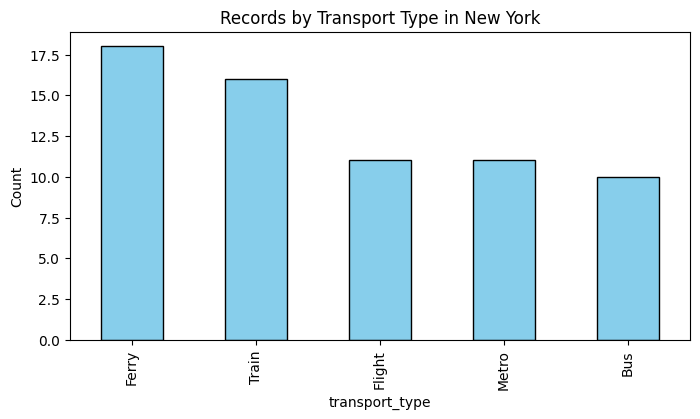

Records per group:
- Bus: 10 entries
- Ferry: 18 entries
- Flight: 11 entries
- Metro: 11 entries
- Train: 16 entries


In [13]:
# Subtask 4.1 & 4.2: Grouping
transport_counts = city_df['transport_type'].value_counts()

# Visualization of transport distribution in NY
plt.figure(figsize=(8, 4))
transport_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title(f'Records by Transport Type in {target_city}')
plt.ylabel('Count')
plt.show()

# Subtask 4.3: Analyze Groups
print("Records per group:")
for name, group in city_df.groupby('transport_type'):
    print(f"- {name}: {len(group)} entries")

## 📊 Task 5: Delay Analysis

### 💡 ELI10: What are we doing?
This is the 'answer' part of our lab! We calculate the average delay in minutes for each transport type. We will see who is usually on time and who is usually late. We finish by saving our findings into a final report file.

Delay Statistics for New York:


,mean,median,std,count,max
transport_type,,,,,
Bus,13.11,11.70,11.60,10,33.8
Ferry,9.59,9.80,5.35,18,18.7
Flight,28.88,24.90,15.02,11,58.4
Metro,7.34,6.80,2.03,11,12.2
Train,18.28,17.55,5.75,16,28.7


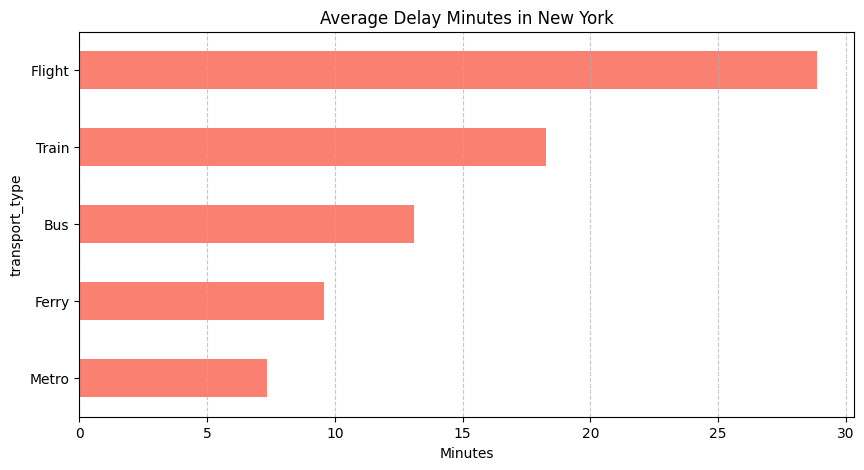

TRANSPORTATION DELAY REPORT: NEW YORK
Most Reliable: Metro (7.34 min avg)
Least Reliable: Flight (28.88 min avg)

Success: Report saved as new_york_delay_analysis.csv


In [14]:
# Subtask 5.1 & 5.2: Calculate Stats
avg_delay_by_transport = city_df.groupby('transport_type')['delay_minutes'].agg([
    'mean', 'median', 'std', 'count', 'max'
]).round(2)

print(f"Delay Statistics for {target_city}:")
display(avg_delay_by_transport)

# Subtask 5.3: Visualize Average Delays
plt.figure(figsize=(10, 5))
avg_delay_by_transport['mean'].sort_values().plot(kind='barh', color='salmon')
plt.title(f'Average Delay Minutes in {target_city}')
plt.xlabel('Minutes')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Subtask 5.4: Final Analysis Report
print("=" * 40)
print("TRANSPORTATION DELAY REPORT: " + target_city.upper())
print("=" * 40)
best = avg_delay_by_transport['mean'].idxmin()
worst = avg_delay_by_transport['mean'].idxmax()

print(f"Most Reliable: {best} ({avg_delay_by_transport.loc[best, 'mean']} min avg)")
print(f"Least Reliable: {worst} ({avg_delay_by_transport.loc[worst, 'mean']} min avg)")

# Export to CSV
output_file = 'new_york_delay_analysis.csv'
avg_delay_by_transport.to_csv(output_file)
print(f"\nSuccess: Report saved as {output_file}")

## ✅ Verification

### 💡 ELI10: What are we doing?
We double-check our work. Did we actually create the file? Is the data inside it correct? This is like checking your answers after a test.

In [15]:
# Check if the output file exists in the current directory
if os.path.exists('new_york_delay_analysis.csv'):
    print("✅ Verification Passed: Analysis CSV found.")
    # Peek at the saved file to ensure data is correct
    check_df = pd.read_csv('new_york_delay_analysis.csv')
    display(check_df.head())
else:
    print("❌ Verification Failed: File not found.")

✅ Verification Passed: Analysis CSV found.


,transport_type,mean,median,std,count,max
0,Bus,13.11,11.70,11.60,10,33.8
1,Ferry,9.59,9.80,5.35,18,18.7
2,Flight,28.88,24.90,15.02,11,58.4
3,Metro,7.34,6.80,2.03,11,12.2
4,Train,18.28,17.55,5.75,16,28.7


## 🛠 Troubleshooting
*   **CSV File Not Found:** Ensure you ran the "Creating the Transportation Dataset" cell first.
*   **Date Errors:** If `pd.to_datetime` fails, we used `errors='coerce'` which turns bad dates into `NaT` (Not a Time) instead of crashing the program.
*   **Missing Data:** If your charts look empty, make sure you didn't accidentally filter out all rows (e.g., searching for a city that isn't in the list).

## 📚 Key Takeaways
1.  **Standardization is Key:** Cleaning time and date formats is 80% of the work in real-world data science.
2.  **Grouping Reveals Patterns:** Overall averages can hide details; grouping by 'Transport Type' shows which specific systems are failing.
3.  **Handling Midnight:** When calculating arrival times, always check if the arrival is on the next day.

## 🏁 Conclusion
Congratulations! You have successfully transformed a messy, raw dataset of transport times into a clear, visual report showing delay patterns in New York City. These skills are used every day by logistics companies and city planners to make travel better for everyone.